Running experiment with KL divergence regularization

Training Task 1
Epoch 200, Loss: 0.6655
Epoch 400, Loss: 3.2806
Epoch 600, Loss: 1.3581
Epoch 800, Loss: 2.7567
Epoch 1000, Loss: 0.7892


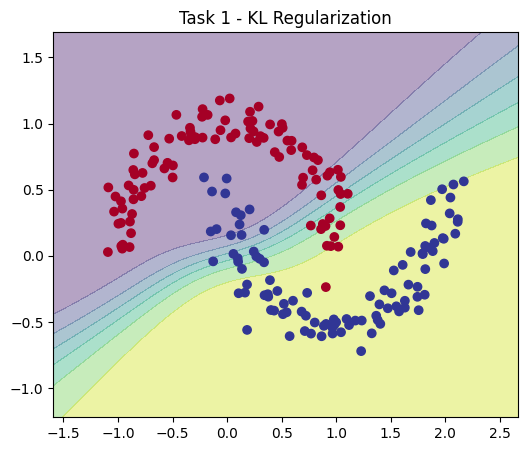


Training Task 2
Epoch 200, Loss: 1.4120
Epoch 400, Loss: 1.1784
Epoch 600, Loss: 2.1593
Epoch 800, Loss: 2.9340
Epoch 1000, Loss: 1.2831


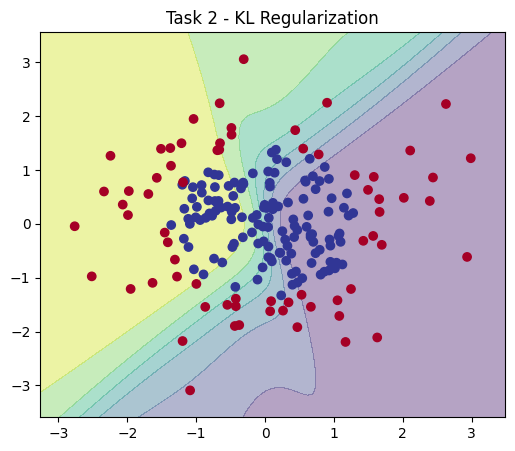


Training Task 3
Epoch 200, Loss: 1.7539
Epoch 400, Loss: 1.6727
Epoch 600, Loss: 1.2977
Epoch 800, Loss: 1.2603
Epoch 1000, Loss: 1.1822


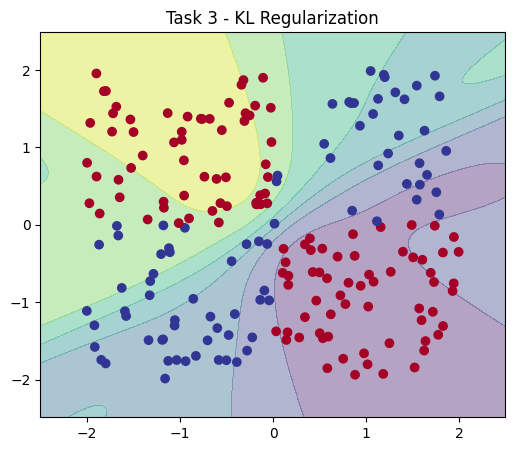


Running experiment with Rényi divergence regularization

Training Task 1
Epoch 200, Loss: -3.1176
Epoch 400, Loss: -7.1911
Epoch 600, Loss: -11.5787
Epoch 800, Loss: -12.0601
Epoch 1000, Loss: -17.9925


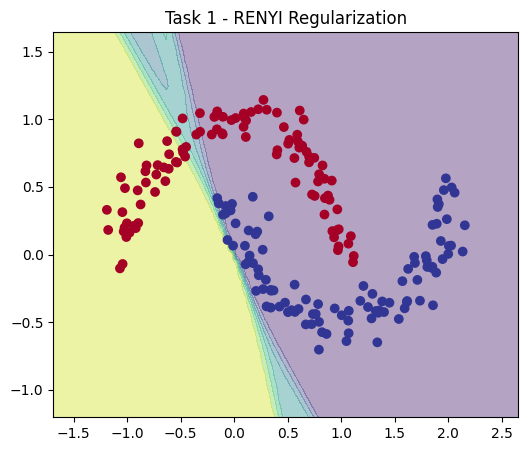


Training Task 2
Epoch 200, Loss: -18.9949
Epoch 400, Loss: -21.7927
Epoch 600, Loss: -26.1241
Epoch 800, Loss: -28.4079
Epoch 1000, Loss: -18.6092


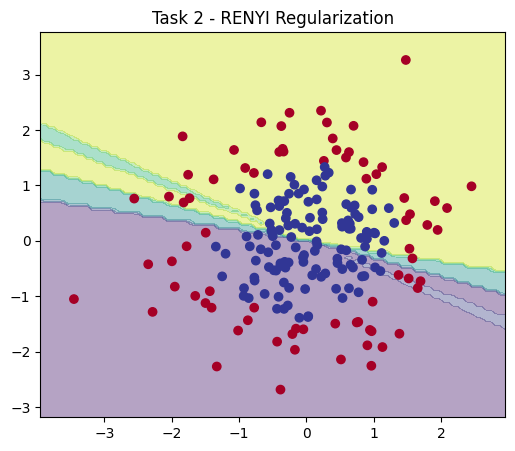


Training Task 3
Epoch 200, Loss: -33.1993
Epoch 400, Loss: -34.8194
Epoch 600, Loss: -35.0898
Epoch 800, Loss: -36.8196
Epoch 1000, Loss: -38.7874


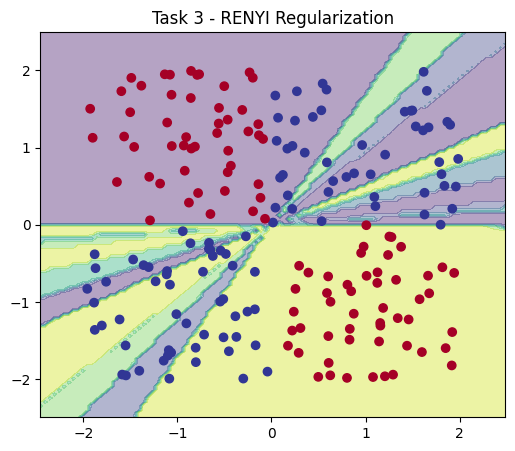

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

class BayesianNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32):
        super().__init__()
        # Mean and log variance for weights of first layer
        self.w1_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.1)
        self.w1_logvar = nn.Parameter(torch.zeros(input_dim, hidden_dim))
        
        # Mean and log variance for weights of second layer
        self.w2_mu = nn.Parameter(torch.randn(hidden_dim, 1) * 0.1)
        self.w2_logvar = nn.Parameter(torch.zeros(hidden_dim, 1))
        
        # Prior parameters
        self.prior_mu = 0.0
        self.prior_std = 1.0

    def sample_weights(self):
        # Sample weights using reparametrization trick
        eps1 = torch.randn_like(self.w1_mu)
        w1 = self.w1_mu + torch.exp(0.5 * self.w1_logvar) * eps1
        
        eps2 = torch.randn_like(self.w2_mu)
        w2 = self.w2_mu + torch.exp(0.5 * self.w2_logvar) * eps2
        
        return w1, w2

    def forward(self, x, num_samples=1):
        batch_size = x.size(0)
        outputs = []
        
        for _ in range(num_samples):
            w1, w2 = self.sample_weights()
            h = torch.tanh(x @ w1)
            out = torch.sigmoid(h @ w2)
            outputs.append(out)
            
        return torch.stack(outputs, dim=0).mean(dim=0)

    def kl_divergence(self):
        # KL divergence between posterior and prior for all weights
        kl_w1 = self._kl_normal(self.w1_mu, self.w1_logvar)
        kl_w2 = self._kl_normal(self.w2_mu, self.w2_logvar)
        return kl_w1 + kl_w2

    def renyi_divergence(self, alpha=0.5):
        # Rényi divergence between posterior and prior for all weights
        renyi_w1 = self._renyi_normal(self.w1_mu, self.w1_logvar, alpha)
        renyi_w2 = self._renyi_normal(self.w2_mu, self.w2_logvar, alpha)
        return renyi_w1 + renyi_w2

    def _kl_normal(self, mu, logvar):
        var = torch.exp(logvar)
        kl = 0.5 * torch.sum(
            var/self.prior_std**2 + (mu - self.prior_mu)**2/self.prior_std**2 - 1 - logvar
        )
        return kl

    def _renyi_normal(self, mu, logvar, alpha):
        var = torch.exp(logvar)
        renyi = (1/(alpha - 1)) * torch.sum(
            torch.log(
                (self.prior_std/(torch.sqrt(var)))**(alpha-1) * 
                torch.exp(-0.5 * alpha * (mu - self.prior_mu)**2 / 
                         (self.prior_std**2))
            )
        )
        return renyi

def generate_task_data(task_id, n_samples=200):
    if task_id == 0:
        # Task 1: Two moons
        X, y = make_moons(n_samples=n_samples, noise=0.1)
    elif task_id == 1:
        # Task 2: Circular data
        X = np.random.randn(n_samples, 2)
        y = (np.sum(X**2, axis=1) < 2).astype(int)
    else:
        # Task 3: XOR-like data
        X = np.random.uniform(-2, 2, (n_samples, 2))
        y = ((X[:, 0] * X[:, 1]) > 0).astype(int)
    
    return torch.FloatTensor(X), torch.FloatTensor(y).reshape(-1, 1)

def train_task(model, X, y, reg_type='kl', n_epochs=1000, alpha=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(X)
        
        # Negative log likelihood loss
        nll = F.binary_cross_entropy(pred, y)
        
        # Regularization
        if reg_type == 'kl':
            reg = 0.1 * model.kl_divergence()
        else:  # renyi
            reg = 0.1 * model.renyi_divergence(alpha)
            
        # Total loss
        loss = nll + reg
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 200 == 0:
            print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

def plot_decision_boundary(model, X, y, title):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Make predictions
    X_test = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(X_test).numpy()
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.show()

# Main execution
def run_experiment(reg_type='kl'):
    model = BayesianNN()
    
    for task_id in range(3):
        print(f"\nTraining Task {task_id + 1}")
        X, y = generate_task_data(task_id)
        
        # Train on current task
        train_task(model, X, y, reg_type=reg_type)
        
        # Visualize decision boundary
        plot_decision_boundary(model, X, y, 
                             f"Task {task_id + 1} - {reg_type.upper()} Regularization")

# Run experiments with both regularization types
print("Running experiment with KL divergence regularization")
run_experiment(reg_type='kl')

print("\nRunning experiment with Rényi divergence regularization")
run_experiment(reg_type='renyi')

In [8]:
import sys
import os

# Add the path to the directory containing toy_data2.py
sys.path.append(os.path.abspath('./src'))

# Import necessary functions and classes from toy_data2.py
from dataloaders.toy_data_2 import get, visualize_data

# Retrieve the data using the get function
data, taskcla, size = get()

# Visualize the data
visualize_data(data)

ImportError: cannot import name 'get' from 'dataloaders.toy_data_2' (/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/toy_data_2.py)

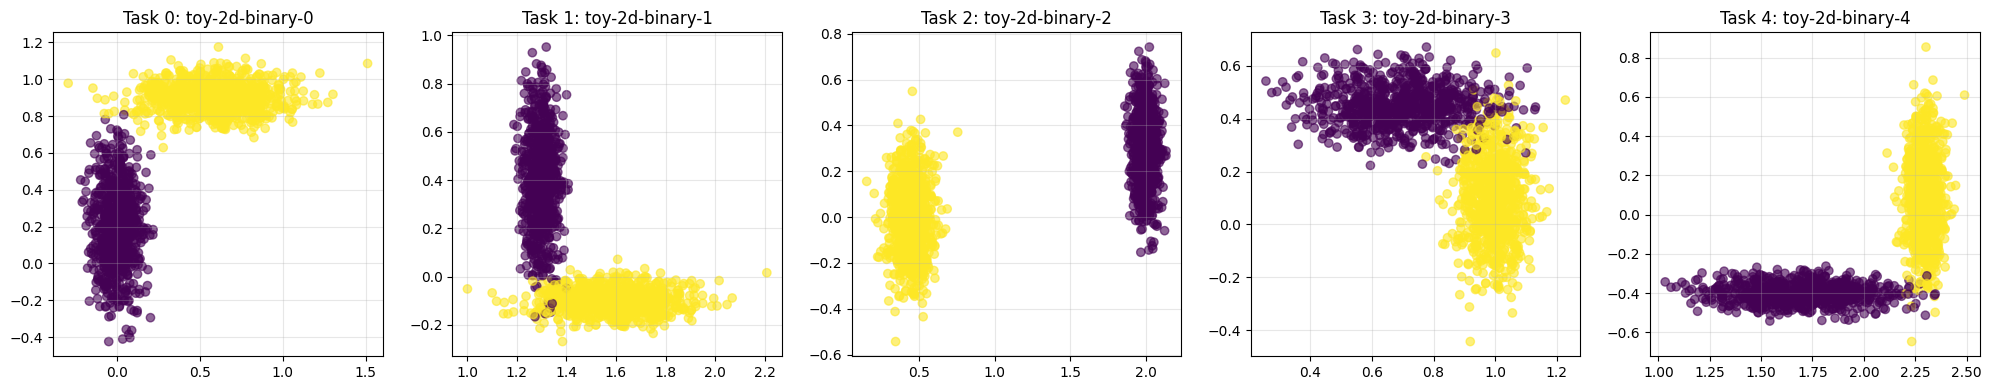

In [41]:
data, taskcla, size = get(seed=0, option = 0)
fig = visualize_tasks(data)

Running experiment with KL divergence regularization

Training Task 1
(Outlier ratio: 0.1)
Epoch 200, Loss: 0.7223
Epoch 400, Loss: 4.3328
Epoch 600, Loss: 1.2617
Epoch 800, Loss: 0.8310
Epoch 1000, Loss: 3.9569


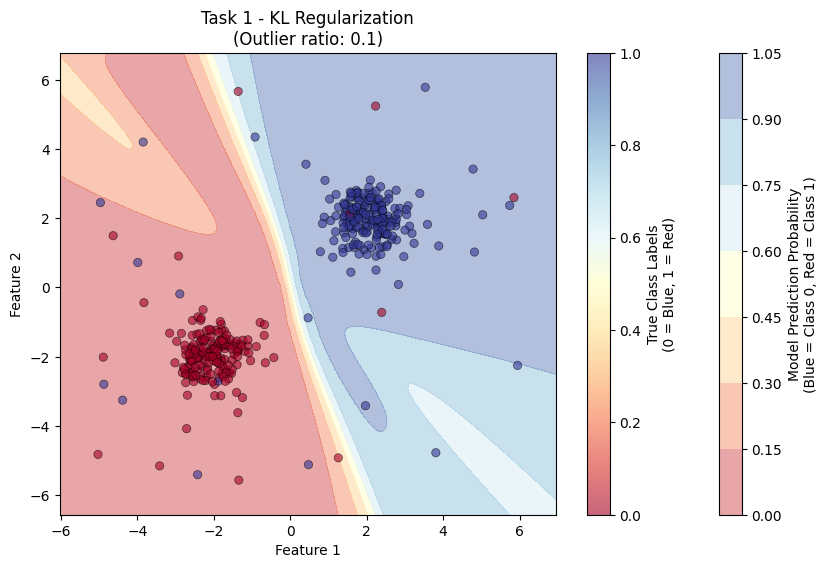


Training Task 2
(Outlier ratio: 0.2)
Epoch 200, Loss: 1.0494
Epoch 400, Loss: 1.5729
Epoch 600, Loss: 1.3737
Epoch 800, Loss: 1.0208
Epoch 1000, Loss: 1.0073


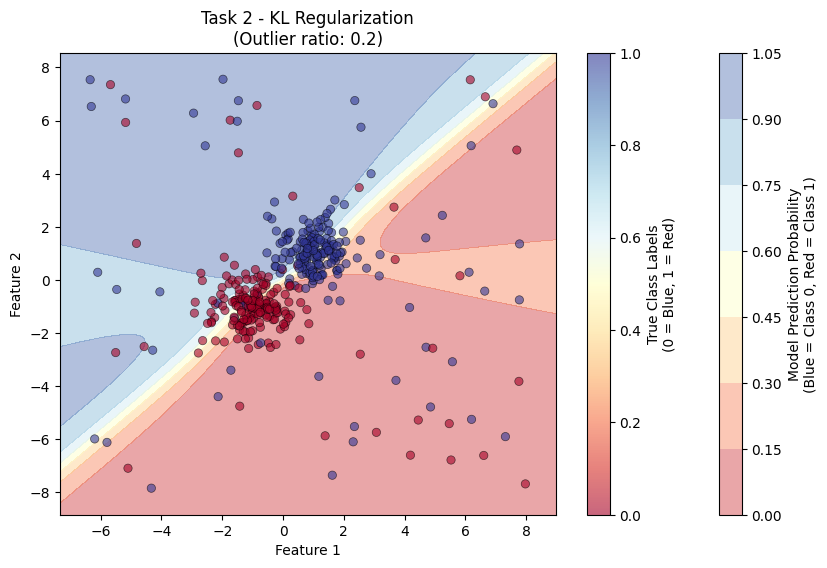


Training Task 3
(Outlier ratio: 0.3)
Epoch 200, Loss: 1.4332
Epoch 400, Loss: 1.8106
Epoch 600, Loss: 1.4532
Epoch 800, Loss: 1.0695
Epoch 1000, Loss: 1.2098


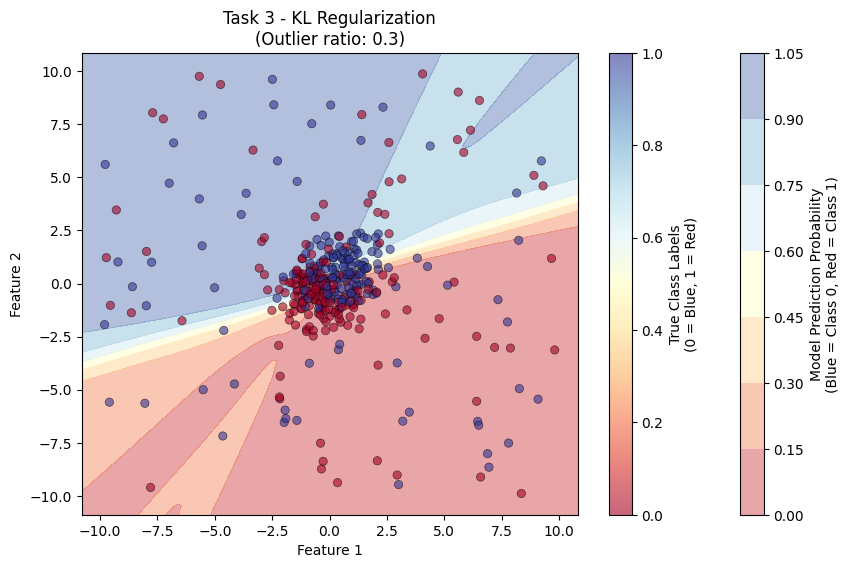

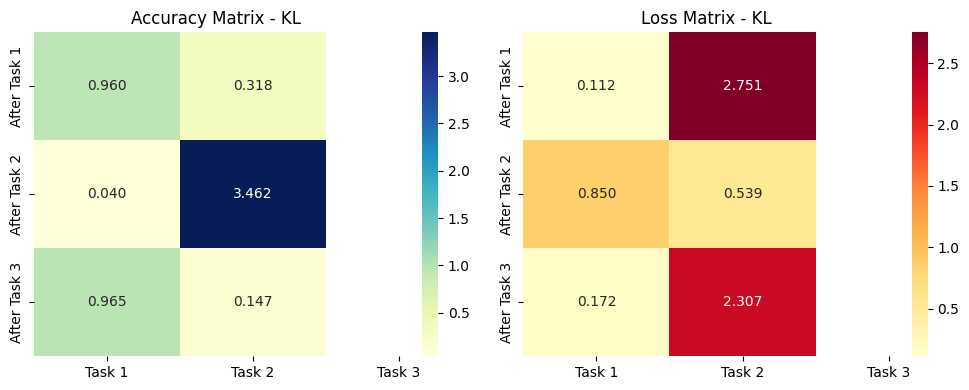


Running experiment with Rényi divergence regularization

Training Task 1
(Outlier ratio: 0.1)
Epoch 200, Loss: -2.0560
Epoch 400, Loss: -0.5981
Epoch 600, Loss: -3.8534
Epoch 800, Loss: -6.3816
Epoch 1000, Loss: -8.4732


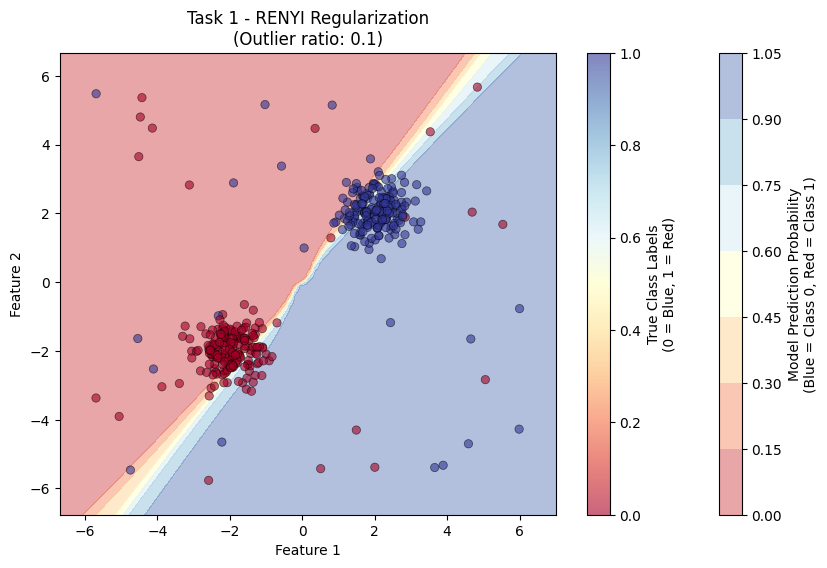


Training Task 2
(Outlier ratio: 0.2)
Epoch 200, Loss: -6.1150
Epoch 400, Loss: -13.7568
Epoch 600, Loss: -16.3158
Epoch 800, Loss: -14.8027
Epoch 1000, Loss: -7.7299


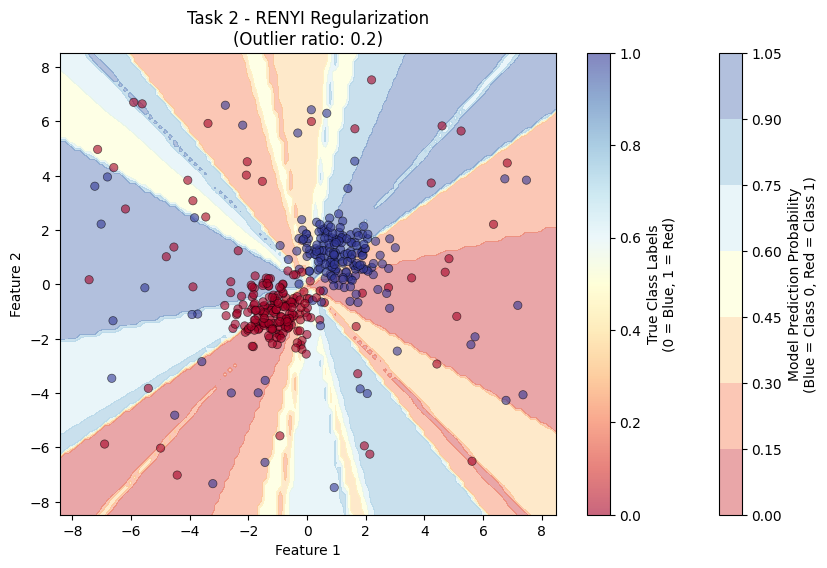


Training Task 3
(Outlier ratio: 0.3)
Epoch 200, Loss: -23.1121
Epoch 400, Loss: -24.8873
Epoch 600, Loss: -19.0323
Epoch 800, Loss: -25.2906
Epoch 1000, Loss: -30.6977


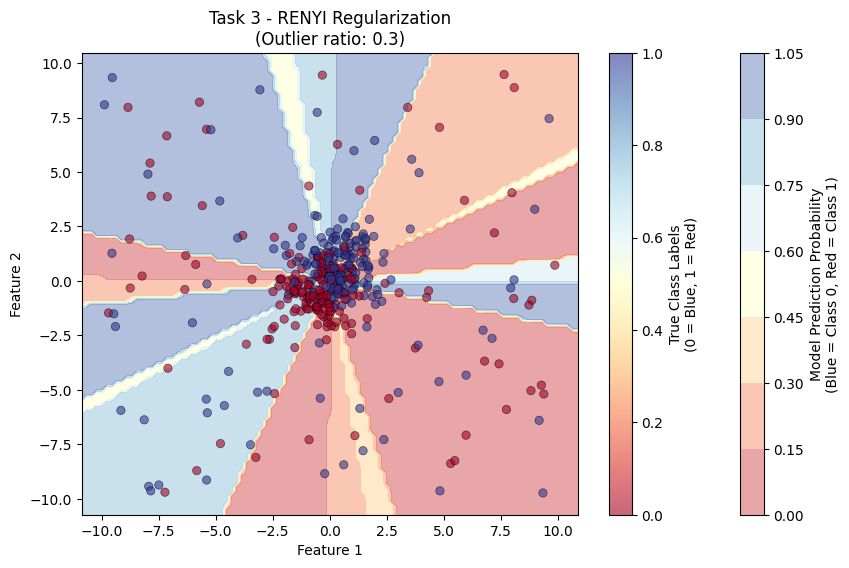

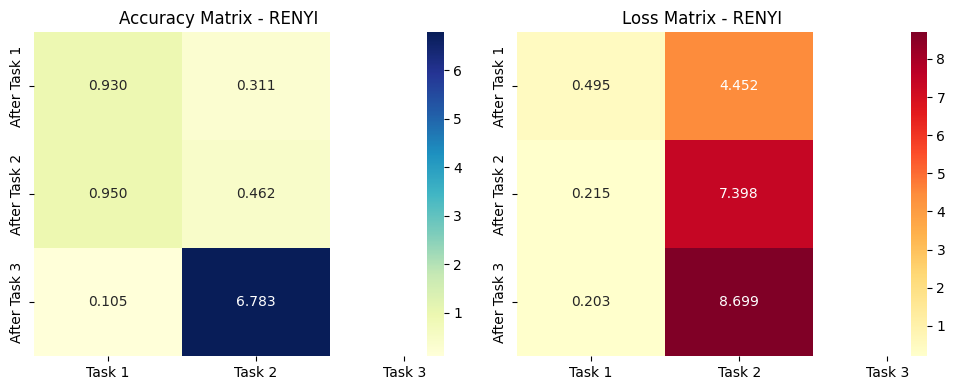


Performance Comparison (Final accuracies after training on all tasks):
Task		KL		Rényi
----------------------------------------
Task 1		0.965		0.105
Task 2		0.172		0.203
Task 3		0.550		0.627


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
import seaborn as sns

class BayesianNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32):
        super().__init__()
        self.w1_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.1)
        self.w1_logvar = nn.Parameter(torch.zeros(input_dim, hidden_dim))
        self.w2_mu = nn.Parameter(torch.randn(hidden_dim, 1) * 0.1)
        self.w2_logvar = nn.Parameter(torch.zeros(hidden_dim, 1))
        self.prior_mu = 0.0
        self.prior_std = 1.0

    def sample_weights(self):
        eps1 = torch.randn_like(self.w1_mu)
        w1 = self.w1_mu + torch.exp(0.5 * self.w1_logvar) * eps1
        eps2 = torch.randn_like(self.w2_mu)
        w2 = self.w2_mu + torch.exp(0.5 * self.w2_logvar) * eps2
        return w1, w2

    def forward(self, x, num_samples=1):
        batch_size = x.size(0)
        outputs = []
        for _ in range(num_samples):
            w1, w2 = self.sample_weights()
            h = torch.tanh(x @ w1)
            out = torch.sigmoid(h @ w2)
            outputs.append(out)
        return torch.stack(outputs, dim=0).mean(dim=0)

    def kl_divergence(self):
        kl_w1 = self._kl_normal(self.w1_mu, self.w1_logvar)
        kl_w2 = self._kl_normal(self.w2_mu, self.w2_logvar)
        return kl_w1 + kl_w2

    def renyi_divergence(self, alpha=0.5):
        renyi_w1 = self._renyi_normal(self.w1_mu, self.w1_logvar, alpha)
        renyi_w2 = self._renyi_normal(self.w2_mu, self.w2_logvar, alpha)
        return renyi_w1 + renyi_w2

    def _kl_normal(self, mu, logvar):
        var = torch.exp(logvar)
        kl = 0.5 * torch.sum(
            var/self.prior_std**2 + (mu - self.prior_mu)**2/self.prior_std**2 - 1 - logvar
        )
        return kl

    def _renyi_normal(self, mu, logvar, alpha):
        var = torch.exp(logvar)
        renyi = (1/(alpha - 1)) * torch.sum(
            torch.log(
                (self.prior_std/(torch.sqrt(var)))**(alpha-1) * 
                torch.exp(-0.5 * alpha * (mu - self.prior_mu)**2 / 
                         (self.prior_std**2))
            )
        )
        return renyi

def generate_gaussian_with_outliers(n_samples, outlier_ratio, task_id):
    """Generate two Gaussian clusters with controlled outlier ratio"""
    n_clean = int(n_samples * (1 - outlier_ratio))
    n_outliers = n_samples - n_clean
    
    # Parameters for the two main Gaussian clusters
    if task_id == 0:
        # Task 1: Well-separated Gaussians with few outliers
        mu1, mu2 = np.array([-2, -2]), np.array([2, 2])
        std1, std2 = 0.5, 0.5
        outlier_scale = 6
    elif task_id == 1:
        # Task 2: Closer Gaussians with moderate outliers
        mu1, mu2 = np.array([-1, -1]), np.array([1, 1])
        std1, std2 = 0.7, 0.7
        outlier_scale = 8
    else:
        # Task 3: Overlapping Gaussians with many outliers
        mu1, mu2 = np.array([-0.5, -0.5]), np.array([0.5, 0.5])
        std1, std2 = 1.0, 1.0
        outlier_scale = 10
    
    # Generate clean samples
    n_clean_per_class = n_clean // 2
    X1 = np.random.normal(mu1, std1, (n_clean_per_class, 2))
    X2 = np.random.normal(mu2, std2, (n_clean_per_class, 2))
    y1 = np.zeros(n_clean_per_class)
    y2 = np.ones(n_clean_per_class)
    
    # Generate outliers
    outliers_X = np.random.uniform(-outlier_scale, outlier_scale, (n_outliers, 2))
    outliers_y = np.random.binomial(1, 0.5, n_outliers)
    
    # Combine clean and outlier data
    X = np.vstack([X1, X2, outliers_X])
    y = np.hstack([y1, y2, outliers_y])
    
    # Shuffle the data
    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]
    
    return torch.FloatTensor(X), torch.FloatTensor(y).reshape(-1, 1)

def generate_task_data(task_id, n_samples=400):
    outlier_ratios = [0.1, 0.2, 0.3]  # Increasing outlier ratio for each task
    return generate_gaussian_with_outliers(n_samples, outlier_ratios[task_id], task_id)

def evaluate_task(model, X, y):
    with torch.no_grad():
        pred = model(X)
        binary_pred = (pred >= 0.5).float()
        accuracy = (binary_pred == y).float().mean()
        loss = F.binary_cross_entropy(pred, y)
    return accuracy.item(), loss.item()

def train_task(model, X, y, reg_type='kl', n_epochs=1000, alpha=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        pred = model(X)
        nll = F.binary_cross_entropy(pred, y)
        
        if reg_type == 'kl':
            reg = 0.1 * model.kl_divergence()
        else:
            reg = 0.1 * model.renyi_divergence(alpha)
            
        loss = nll + reg
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 200 == 0:
            print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    X_test = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(X_test).numpy()
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    
    # Plot decision boundary
    contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    plt.colorbar(contour, label='Model Prediction Probability\n(Blue = Class 0, Red = Class 1)')
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, 
                         alpha=0.6, edgecolor='black', linewidth=0.5)
    plt.colorbar(scatter, label='True Class Labels\n(0 = Blue, 1 = Red)')
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

def plot_performance_matrix(performance_history, reg_type):
    plt.figure(figsize=(10, 4))
    
    # Accuracy subplot
    plt.subplot(1, 2, 1)
    sns.heatmap(np.array([h[0] for h in performance_history]), 
                annot=True, fmt='.3f', cmap='YlGnBu',
                xticklabels=['Task 1', 'Task 2', 'Task 3'],
                yticklabels=['After Task 1', 'After Task 2', 'After Task 3'])
    plt.title(f'Accuracy Matrix - {reg_type.upper()}')
    
    # Loss subplot
    plt.subplot(1, 2, 2)
    sns.heatmap(np.array([h[1] for h in performance_history]), 
                annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=['Task 1', 'Task 2', 'Task 3'],
                yticklabels=['After Task 1', 'After Task 2', 'After Task 3'])
    plt.title(f'Loss Matrix - {reg_type.upper()}')
    plt.tight_layout()
    plt.show()

def run_experiment(reg_type='kl'):
    model = BayesianNN()
    task_data = [generate_task_data(i) for i in range(3)]
    performance_history = []
    
    for current_task in range(3):
        print(f"\nTraining Task {current_task + 1}")
        print(f"(Outlier ratio: {[0.1, 0.2, 0.3][current_task]})")
        X, y = task_data[current_task]
        
        # Train on current task
        train_task(model, X, y, reg_type=reg_type)
        
        # Evaluate on all tasks
        task_performances = []
        for task_id in range(3):
            X_eval, y_eval = task_data[task_id]
            acc, loss = evaluate_task(model, X_eval, y_eval)
            task_performances.append((acc, loss))
        performance_history.append(task_performances)
        
        # Visualize decision boundary
        plot_decision_boundary(model, X, y, 
                             f"Task {current_task + 1} - {reg_type.upper()} Regularization\n"
                             f"(Outlier ratio: {[0.1, 0.2, 0.3][current_task]})")
    
    plot_performance_matrix(performance_history, reg_type)
    return performance_history

# Run experiments with both regularization types
print("Running experiment with KL divergence regularization")
kl_performance = run_experiment(reg_type='kl')

print("\nRunning experiment with Rényi divergence regularization")
renyi_performance = run_experiment(reg_type='renyi')

# Compare regularization methods
def print_comparison(kl_perf, renyi_perf):
    print("\nPerformance Comparison (Final accuracies after training on all tasks):")
    print("Task\t\tKL\t\tRényi")
    print("-" * 40)
    for i in range(3):
        kl_acc = kl_perf[-1][i][0]
        renyi_acc = renyi_perf[-1][i][0]
        print(f"Task {i+1}\t\t{kl_acc:.3f}\t\t{renyi_acc:.3f}")

print_comparison(kl_performance, renyi_performance)

In [29]:
import subprocess

# Define the parameters
experiment = "toy2d"
approach = "toy2d"
reg_type = "re_g"
dof = [50]
seed = 187

# Loop over the seeds and run the experiment
for v in dof:
    print(f"Running experiment with dof {v}")
    subprocess.run([
        "python", "./src/run.py",
        "--experiment", experiment,
        "--approach", approach,
        "--seed", str(seed),
        "--use-sweep", str(True),
        "--reg_type", reg_type
    ])

Running experiment with dof 50


wandb: Currently logged in as: naima-elosegui (nagiu). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Tracking run with wandb version 0.19.3
wandb: Run data is saved locally in /home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/wandb/run-20250129_191701-tg5t0c3b
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fine-eon-2919
wandb: ⭐️ View project at https://wandb.ai/nagiu/curvy-cl
wandb: 🚀 View run at https://wandb.ai/nagiu/curvy-cl/runs/tg5t0c3b


Arguments =
	sweep_name: None
	seed: 187
	experiment: toy2d
	approach: toy2d
	reg_type: re_g
	q: 1.01
	v: 1
	output: ./res/toy2d/toy2d_re_g_187.txt
	nepochs: None
	lr: -1
	parameter: 
	ntasks: -1
	context: None
	momentum: 0.9
	weight_decay: 0.0001
	beta: 1
	lamb: 1
	root_path: ./
	use_best_hyperparams: False
	use_sweep: True
	train_samples: 10
	lr_schedule: False
	scheduler_type: cosine_anneal
	sbatch: 64
	optimizer: sgd
Load data...
Input size = [2] 
Task info = [(0, 2), (1, 2), (2, 2), (3, 2), (4, 2)]
Inits...
----------------------------------------------------------------------------------------------------
Net(
  (fc_layers): ModuleList(
    (0-1): 2 x MFLinearLayer()
  )
  (heads): ModuleList(
    (0-4): 5 x MFLinearLayer()
  )
)
Dimensions = torch.Size([32, 2]) torch.Size([32]) torch.Size([32, 2]) torch.Size([32]) torch.Size([32, 32]) torch.Size([32]) torch.Size([32, 32]) torch.Size([32]) torch.Size([2, 32]) torch.Size([2]) torch.Size([2, 32]) torch.Size([2]) torch.Size([2, 32])

wandb:                                                                                
wandb: 
wandb: Run history:
wandb:     avg_accuracy ▁▃▅▆█
wandb:       class_loss █▆▃▂▁▁▁▁▁█▅▄▄▃▃▃▇▃▁▁▁▁▁▁▁▇▆▅▄▄▄▄█▄▂▂▂▂▂▂
wandb:            epoch ▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇█████
wandb:          kl_loss ▁▁▁▁▁▁▁▁▁▇▁▁▁▁▁▁▁▇▁▁▁▁▁▁▁█▁▁▁▁▁▁█▁▁▁▁▁▁▁
wandb:               lr █▇▇▆▅▂▂▁▁█▇▆▅▃▂▁▁█▇▇▅▃▂▂▁█▇▆▅▃▂▁▁█▇▆▃▂▂▁
wandb:  test_acc_task_0 █▅▇▂▁
wandb:  test_acc_task_1 █▁▃█
wandb:  test_acc_task_2 █▁█
wandb:  test_acc_task_3 █▁
wandb:  test_acc_task_4 ▁
wandb: test_loss_task_0 ▁▁▁▁▁
wandb: test_loss_task_1 ▁▁▁▁
wandb: test_loss_task_2 ▁▁▁
wandb: test_loss_task_3 ▁▁
wandb: test_loss_task_4 ▁
wandb:       total_loss ▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▇▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁█▁▁▁▁▁▁▁
wandb:        train_acc ▄▇███████▄▇▇▇▇▇▇▇▃███████▅▆▇▇▇▇▇▇▁██████
wandb: 
wandb: Run summary:
wandb:     avg_accuracy 0.946
wandb:       class_loss 0.00155
wandb:            epoch 50
wandb:          kl_loss 0.00066
wandb:               lr 1e-05
wandb:

| Epoch   1, time=  8.3ms| Train: class_loss=0.011  kl_loss=0.168 total_loss=0.179, acc= 59.5% |
| Epoch   2, time=  8.1ms| Train: class_loss=0.010  kl_loss=0.008 total_loss=0.018, acc= 81.9% |
| Epoch   3, time=  8.7ms| Train: class_loss=0.008  kl_loss=0.002 total_loss=0.009, acc= 89.4% |
| Epoch   4, time=  8.5ms| Train: class_loss=0.006  kl_loss=0.002 total_loss=0.008, acc= 90.9% |
| Epoch   5, time=  8.5ms| Train: class_loss=0.006  kl_loss=0.002 total_loss=0.007, acc= 91.2% |
| Epoch   6, time=  8.5ms| Train: class_loss=0.005  kl_loss=0.002 total_loss=0.007, acc= 92.4% |
| Epoch   7, time=  8.5ms| Train: class_loss=0.005  kl_loss=0.002 total_loss=0.007, acc= 92.4% |
| Epoch   8, time=  8.5ms| Train: class_loss=0.005  kl_loss=0.002 total_loss=0.007, acc= 92.2% |
| Epoch   9, time=  8.5ms| Train: class_loss=0.005  kl_loss=0.002 total_loss=0.007, acc= 92.4% |
| Epoch  10, time=  8.6ms| Train: class_loss=0.005  kl_loss=0.002 total_loss=0.007, acc= 92.1% |
------------------------------

In [41]:
import numpy as np

# Path to the .npy file
file_path = 'res/toy2d/toy2d_re_g_187_output_dict.npy'

# Load the .npy file
output_dict = np.load(file_path, allow_pickle=True).item()

# Access the contents of the dictionary
for task, output in output_dict.items():
    print(f'{task}: {output}')

task_0: {'output': [tensor([[[ 1.0759, -1.0246],
         [-2.1586,  2.6867],
         [ 1.9278, -2.0280],
         [ 1.7481, -1.5139],
         [ 1.2932, -1.1056],
         [-2.4889,  3.5241],
         [-3.5123,  3.9595],
         [-2.7249,  3.6800]],

        [[ 0.9165, -0.6213],
         [-2.0729,  2.6679],
         [ 2.0716, -2.0654],
         [ 1.8419, -1.6763],
         [ 0.9597, -0.6676],
         [-2.9183,  3.3656],
         [-3.1060,  3.8291],
         [-3.1395,  3.7137]],

        [[ 1.1431, -0.7491],
         [-1.7863,  2.5317],
         [ 1.9676, -1.8728],
         [ 2.0447, -1.7190],
         [ 1.0941, -0.8547],
         [-2.7186,  3.2618],
         [-3.2113,  3.8669],
         [-2.9501,  3.8195]],

        [[ 1.1976, -0.9336],
         [-2.0437,  2.8398],
         [ 2.0604, -1.9053],
         [ 1.8382, -1.7025],
         [ 0.8632, -0.7460],
         [-2.5523,  3.3248],
         [-3.3249,  3.8198],
         [-3.0622,  3.7549]],

        [[ 1.0091, -0.5787],
         [-2.11

In [42]:
out = output_dict['task_0']['output']

In [46]:
len(out)

5

In [35]:
for task, data in output_dict.items():
    xtest = data['xtest']
    ytest = data['ytest']
    output = data['output']
    
    # Convert output to probabilities
    output_tensor = torch.tensor(output)
    probs = F.softmax(output_tensor, dim=2).mean(dim=0)
    _, pred = probs.max(1)
    
    # Convert predictions to numpy array
    pred_np = pred.cpu().numpy()
    
    # Plot the data points
    plt.figure(figsize=(10, 6))
    plt.scatter(xtest[:, 0], xtest[:, 1], c=ytest, cmap='viridis', marker='o', edgecolor='k', s=50, label='True Labels')
    plt.scatter(xtest[:, 0], xtest[:, 1], c=pred_np, cmap='coolwarm', marker='x', s=50, label='Predicted Labels')
    
    # Generate a mesh grid for decision boundary
    x_min, x_max = xtest[:, 0].min() - 1, xtest[:, 0].max() + 1
    y_min, y_max = xtest[:, 1].min() - 1, xtest[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Evaluate the model on the mesh grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    task_labels = int(task.split('_')[1]) * torch.ones(grid_tensor.shape[0], dtype=torch.int64)
    grid_output = output_tensor[:, :grid_tensor.shape[0], :]
    grid_probs = F.softmax(grid_output, dim=2).mean(dim=0)
    _, grid_pred = grid_probs.max(1)
    grid_pred_np = grid_pred.cpu().numpy().reshape(xx.shape)
    
    # Plot the decision boundary
    plt.contourf(xx, yy, grid_pred_np, alpha=0.3, cmap='coolwarm')
    plt.title(f'Decision Boundary for {task}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.colorbar()
    plt.show()

ValueError: only one element tensors can be converted to Python scalars

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Load the output_dict
output_file = 'res/toy2d/toy2d_re_g_187_output_dict.npy'
output_dict = np.load(output_file, allow_pickle=True).item()

for task, data in output_dict.items():
    output = data['output']
    probs = F.softmax(output, dim=2).mean(dim=0)
    
    # Convert probabilities to numpy array
    probs_np = probs.cpu().numpy()
    
    # Plot the probabilities
    plt.figure(figsize=(10, 6))
    plt.imshow(probs_np, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title(f'Probabilities for {task}')
    plt.xlabel('Classes')
    plt.ylabel('Samples')
    plt.show()

AttributeError: 'list' object has no attribute 'softmax'